# Fig 4.7, 4.8
Symmetric (bistable) biological networks.

In [1]:
using OrdinaryDiffEq
using ModelingToolkit
using Plots
Plots.default(linewidth=2)

Model

In [2]:
@independent_variables t
@variables A(t) B(t)
@parameters k1 k2 k3 k4 n1 n2
D = Differential(t)

eqs = [
    D(A) ~ k1 / (1 + B^n1) - k3 * A,
    D(B) ~ k2 / (1 + A^n2) - k4 * B,
]

@mtkbuild osys = ODESystem(eqs, t)

Model osys:
Equations (2):
  2 standard: see equations(osys)
Unknowns (2): see unknowns(osys)
  A(t)
  B(t)
Parameters (6): see parameters(osys)
  k2
  n1
  n2
  k1
  ⋮

## Fig 4.7 A

Asymmetric parameter set

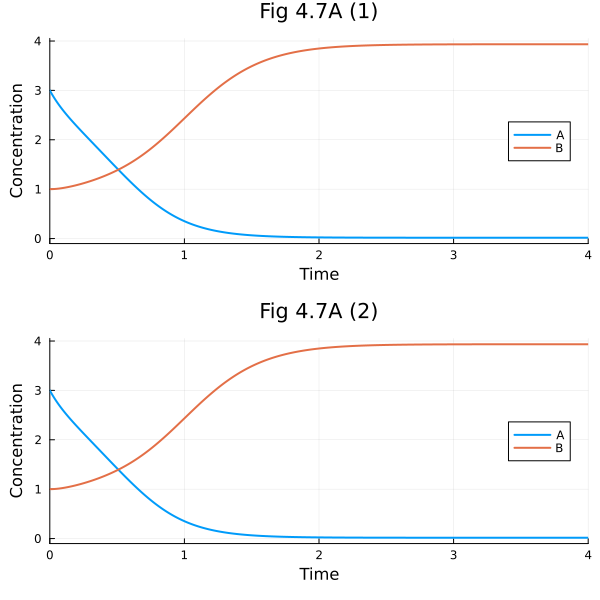

In [3]:
ps1 = Dict(k1=>20, k2=>20, k3=>5, k4=>5, n1=>4, n2=>1)
tend = 4.0
prob47 = ODEProblem(osys, [3, 1], tend, ps1)

sol1 = solve(prob47)
sol2 = solve(remake(prob47, u0=[1, 3]))

ax1 = plot(sol1, xlabel="Time", ylabel="Concentration", legend=:right, title= "Fig 4.7A (1)")
ax2 = plot(sol2, xlabel="Time", ylabel="Concentration", legend=:right, title= "Fig 4.7A (2)")
plot(ax1, ax2, layout=(2, 1), size=(600, 600))

## Fig 4.7 B

In [4]:
∂F47 = function (x, y; scale=20)
    da, db = prob47.f([x, y], prob47.p, nothing)
    s = sqrt(hypot(da, db)) * scale
    return (da / s, db / s)
end

#1 (generic function with 1 method)

Grid points

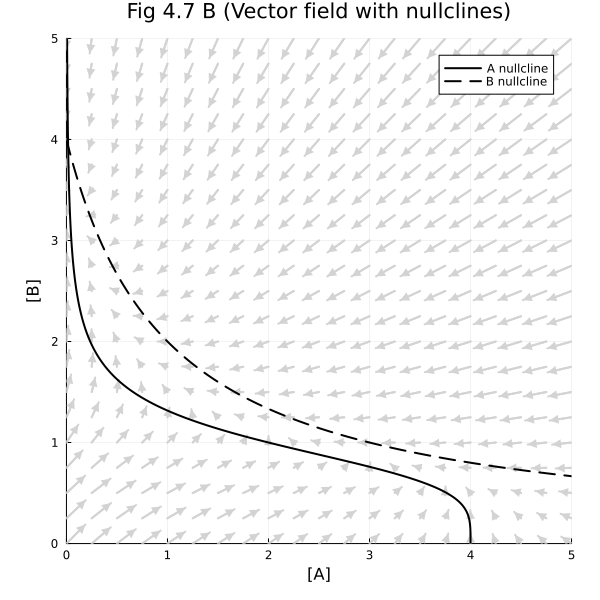

In [5]:
r = range(0, 5, 21)
xx = [x for y in r, x in r]
yy = [y for y in r, x in r];

fig = plot(title="Fig 4.7 B (Vector field with nullclines)")
quiver!(fig, xx, yy, quiver=∂F47, line=(:lightgrey), arrow=(:closed), aspect_ratio=:equal)

∂A47 = (x, y) -> prob47.f([x, y], prob47.p, nothing)[1]
∂B47 = (x, y) -> prob47.f([x, y], prob47.p, nothing)[2]

contour!(fig, 0:0.01:5, 0:0.01:5, ∂A47, levels=[0], cbar=false, line=(:black))
plot!(fig, Float64[], Float64[], line=(:black), label="A nullcline")
contour!(fig, 0:0.01:5, 0:0.01:5, ∂B47, levels=[0], cbar=false, line=(:black, :dash))
plot!(fig, Float64[], Float64[], line=(:black, :dash), label="B nullcline")
plot!(fig, xlim=(0, 5), ylim=(0, 5), legend=:topright, size=(600, 600), xlabel="[A]", ylabel="[B]")

## Fig 4.8

Symmetric parameter set

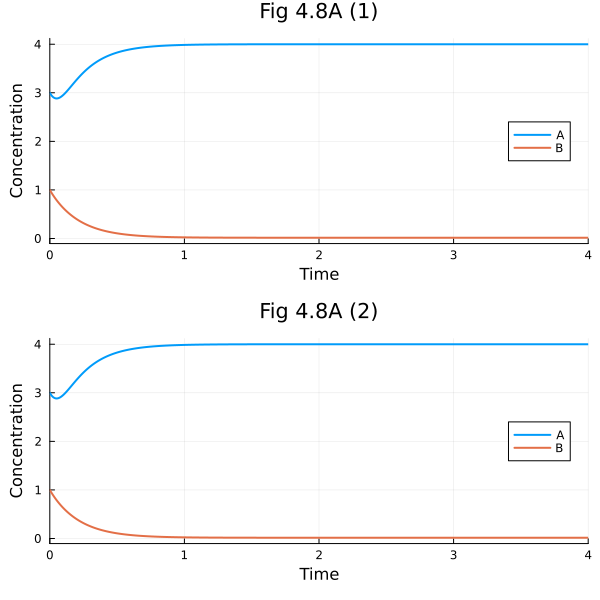

In [6]:
ps2 = Dict(k1=>20, k2=>20, k3=>5, k4=>5, n1=>4, n2=>4)
tend = 4.0
prob48 = ODEProblem(osys, [3, 1], tend, ps2)

sol1 = solve(prob48)
sol2 = solve(remake(prob48, u0=[1, 3]))

ax1 = plot(sol1, xlabel="Time", ylabel="Concentration", legend=:right, title= "Fig 4.8A (1)")
ax2 = plot(sol2, xlabel="Time", ylabel="Concentration", legend=:right, title= "Fig 4.8A (2)")
plot(ax1, ax2, layout=(2, 1), size=(600, 600))

In [7]:
∂F48 = function (x, y; scale=20)
    da, db = prob48.f([x, y], prob48.p, nothing)
    s = sqrt(hypot(da, db)) * scale
    return (da / s, db / s)
end

∂A48 = (x, y) -> prob48.f([x, y], prob48.p, nothing)[1]
∂B48 = (x, y) -> prob48.f([x, y], prob48.p, nothing)[2]

#17 (generic function with 1 method)

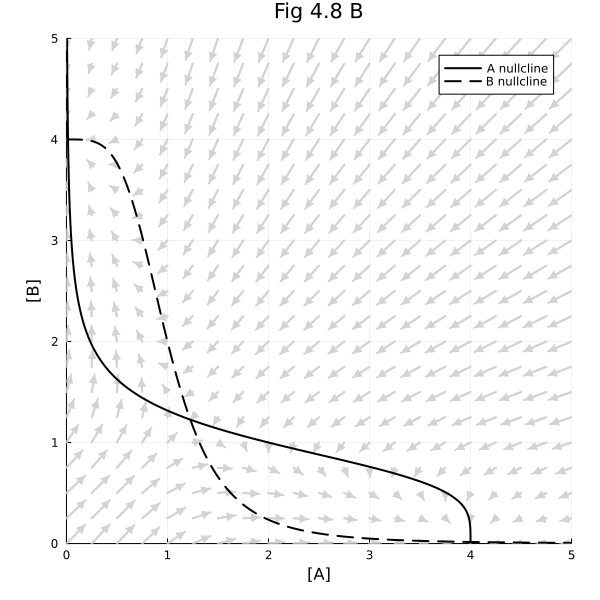

In [8]:
fig = plot(title="Fig 4.8 B")
quiver!(fig, xx, yy, quiver=∂F48, line=(:lightgrey), arrow=(:closed), aspect_ratio=:equal)

contour!(fig, 0:0.01:5, 0:0.01:5, ∂A48, levels=[0], cbar=false, line=(:black))
plot!(fig, Float64[], Float64[], line=(:black), label="A nullcline")
contour!(fig, 0:0.01:5, 0:0.01:5, ∂B48, levels=[0], cbar=false, line=(:black, :dash))
plot!(fig, Float64[], Float64[], line=(:black, :dash), label="B nullcline")
plot!(fig, xlim=(0, 5), ylim=(0, 5), legend=:topright, size=(600, 600), xlabel="[A]", ylabel="[B]")

## Fig 4.8 C
around the unstable steady-state

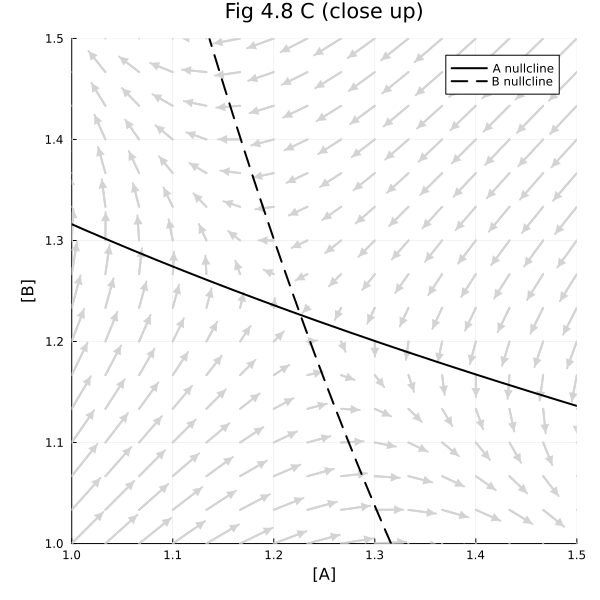

In [9]:
r2 = range(1.0, 1.5, 16)
xx2 = [x for y in r2, x in r2]
yy2 = [y for y in r2, x in r2]

fig = plot(title="Fig 4.8 C (close up)")
quiver!(fig, xx2, yy2, quiver=(x, y)-> ∂F48(x, y; scale=60), line=(:lightgrey), arrow=(:closed), aspect_ratio=:equal)
contour!(fig, 1:0.01:1.5, 1:0.01:1.5, ∂A48, levels=[0], cbar=false, line=(:black))
plot!(fig, Float64[], Float64[], line=(:black), label="A nullcline")
contour!(fig, 1:0.01:1.5, 1:0.01:1.5, ∂B48, levels=[0], cbar=false, line=(:black, :dash))
plot!(fig, Float64[], Float64[], line=(:black, :dash), label="B nullcline")
plot!(fig, xlim=(1, 1.5), ylim=(1, 1.5), legend=:topright, size=(600, 600), xlabel="[A]", ylabel="[B]")

Another way to draw nullclines is to find the analytical solution when dA (or dB) is zero. And then sketch the nullclines in a parameteric plot.

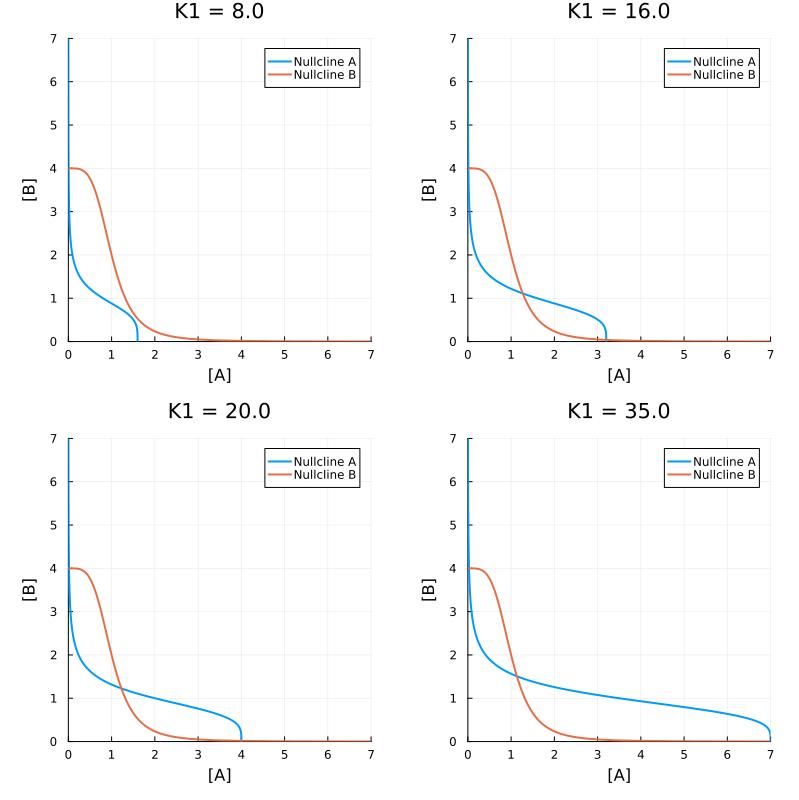

In [10]:
nca47(b, p) = p.k1 / p.k3 / (1 + b^p.n1)
ncb47(a, p) = p.k2 / p.k4 / (1 + a^p.n2)

pls = map((8.0, 16.0, 20.0, 35.0)) do k1
    ps = (k1=k1, k2=20., k3=5., k4=5., n1=4., n2=4.)
    pl = plot(b -> nca47(b, ps), identity, 0., 7., label="Nullcline A")
    plot!(pl, identity, a -> ncb47(a, ps), 0., 7., label="Nullcline B")
    plot!(pl, title = "K1 = $k1", xlim=(0., 7.), ylim=(0., 7.), aspect_ratio = :equal, xlabel="[A]", ylabel="[B]")
    pl
end

plot(pls..., size = (800, 800))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*